In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

processedData = "../../data/processed/dataset_full_preprocessed.csv"
reducedData = "../../data/reduced"
outPath = os.path.join(reducedData, "dataset_fs.csv")

df = pd.read_csv(processedData)
df.shape

y = df["Class"]
X = df.drop(columns=["Class"])

In [8]:
vt = VarianceThreshold(threshold=0.01)
X_var = vt.fit_transform(X)

selected_variance_features = X.columns[vt.get_support()]
df_var = pd.DataFrame(X_var, columns=selected_variance_features)

print("After variance threshold:", df_var.shape)

After variance threshold: (13910, 129)


In [9]:
corr_matrix = df_var.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

correlation_threshold = 0.9
to_drop = [
    column for column in upper.columns
    if any(upper[column] > correlation_threshold)
]

df_fs = df_var.drop(columns=to_drop)

print("After correlation pruning:", df_fs.shape)

After correlation pruning: (13910, 29)


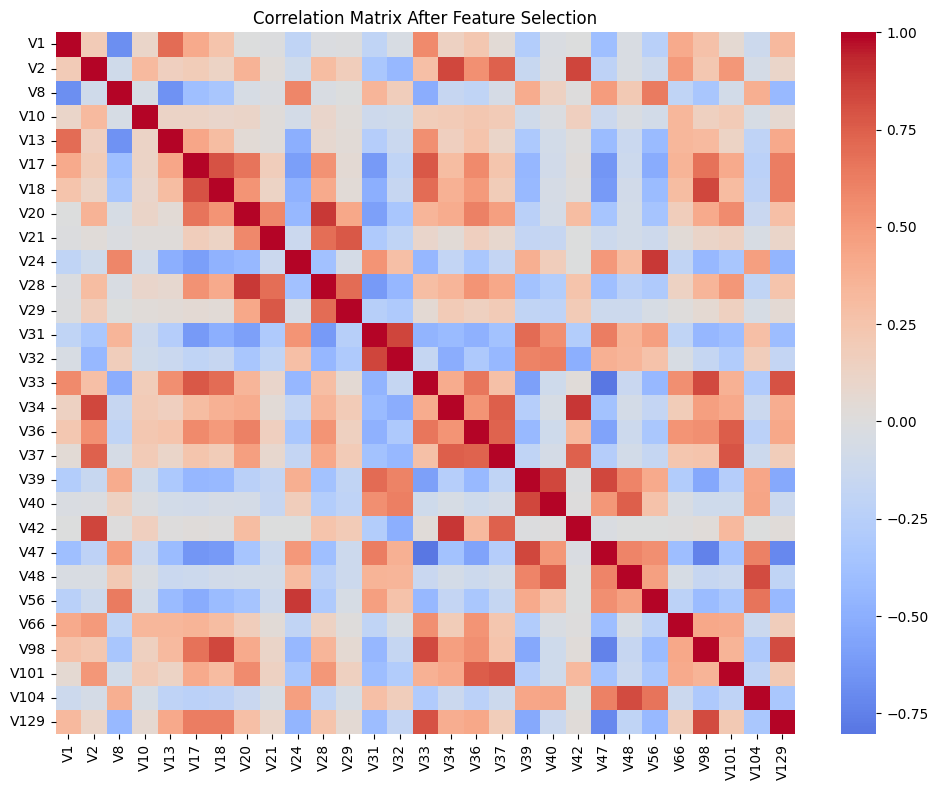

In [10]:
df_fs.to_csv(outPath, index=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df_fs.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix After Feature Selection")
plt.tight_layout()
plt.show()